In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
import yaml
import time
from itertools import combinations
import gget

# from pycirclize import Circos
# from pycirclize.parser import Matrix
# from pycirclize.utils import ColorCycler

# from matplotlib_venn import venn3_unweighted
import matplotlib.colors as mcolors

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

# Load gene data

In [2]:
%%time
# path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
gdata = sc.read_h5ad(path)
gdata

CPU times: user 549 ms, sys: 2.2 s, total: 2.75 s
Wall time: 4.48 s


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

# Load isoform data

In [3]:
%%time

path = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/isoforms.h5ad"
adata = sc.read_h5ad(path)
adata.var.set_index('transcript_name', inplace=True)
print(adata)
adata.var.head()

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
CPU times: user 349 ms, sys: 371 ms, total: 720 ms
Wall time: 1.38 s


,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790
CYP26B1-201,ENSG00000003137,CYP26B1,protein_coding,protein_coding,chr2,72129237,72147862,ENST00000001146,Q9NR63


In [4]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in gdata: {gdata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(gdata.obs_names)
print(f"Number of cells in adata after filtering by gdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = gdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
gdata_sorted = gdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == gdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and bdata (shared cells).")
adata

Initial number of cells in adata: 19858
Number of cells in gdata: 15950
Number of cells in adata after filtering by gdata: 15950
Final number of cells in adata: 15950
Number of shared cells: 15950
Cell ordering is identical between adata and bdata (shared cells).
CPU times: user 1.62 s, sys: 3.26 s, total: 4.88 s
Wall time: 4.93 s


AnnData object with n_obs × n_vars = 15950 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

Before merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts']
After merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata']
AnnData object with n_obs × n_vars = 15950 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap'
    obsm: 'X_umap'


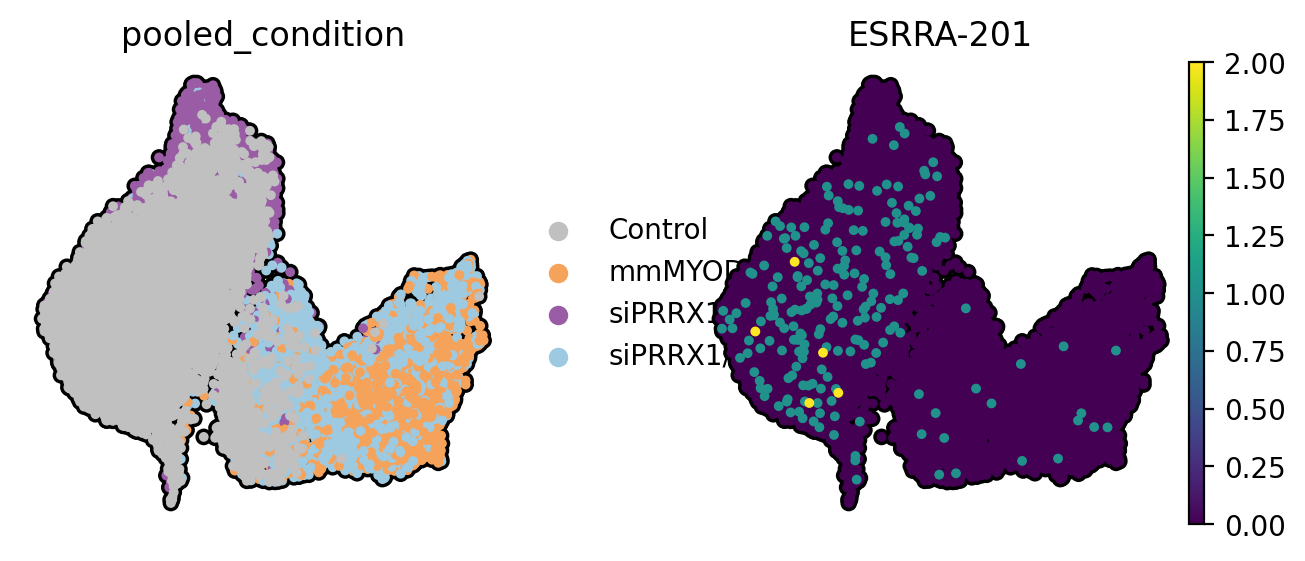

CPU times: user 1.08 s, sys: 97.2 ms, total: 1.18 s
Wall time: 1.23 s


In [5]:
%%time

obs_columns = [
    'leiden_split',
    'pooled_condition',
    'phase',
    'dataset',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = gdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_gdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")

# Add uns
adata.uns['leiden_split_colors'] = gdata.uns['leiden_split_colors'].copy()
adata.uns['dataset_colors'] = gdata.uns['dataset_colors'].copy()
adata.uns['pooled_condition_colors'] = gdata.uns['pooled_condition_colors'].copy()

# Merge embeddings
adata.obsm['X_umap'] = gdata.obsm['X_umap'].copy()
adata.uns['umap'] = gdata.uns['umap'].copy()

print(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    ncols=2,
    sort_order=True,
    color=['pooled_condition', 'ESRRA-201'],
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [6]:
sc.pp.filter_genes(adata, min_counts=20)

adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 32111 genes that are detected in less than 20 counts
normalizing counts per cell
    finished (0:00:03)


AnnData object with n_obs × n_vars = 15950 × 57459
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'n_counts'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

# DGE

In [7]:
%%time

sc.tl.rank_genes_groups(
    adata, 
    groupby='leiden_split',
    method='wilcoxon',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='cluster_deg',
)

sc.tl.rank_genes_groups(
    adata, 
    groupby='pooled_condition',
    method='wilcoxon',
    reference='Control',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_deg',
)

ranking genes
    finished (0:00:57)
ranking genes
    finished (0:01:41)
CPU times: user 2min 10s, sys: 27.8 s, total: 2min 37s
Wall time: 2min 39s


In [8]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            # make sure either group of interest OR reference has % cells expressing above threshold
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of group OR reference cells.")
        
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [9]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_deg',
)

sig = get_significant_DEGs(deg, logfc_thresh=0.5, pct_nz_thresh=0.3)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed genes expressed in less than 30.0% of group OR reference cells.
N unique significant DEGs: 3373



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
0,C1,TPT1-212,101.957344,6.954147,0.0,0.0,1.000000,0.089242,6.954147
1,C1,RPL34-201,101.452110,4.998673,0.0,0.0,1.000000,0.704417,4.998673
2,C1,CST3-201,100.307320,3.039690,0.0,0.0,0.999177,0.663391,3.039690
3,C1,COL1A2-201,100.143852,5.677250,0.0,0.0,0.999835,0.253343,5.677250
4,C1,DCN-220,100.086845,5.981620,0.0,0.0,0.980092,0.082962,5.981620


In [10]:
sig['gene_name'] = sig['names'].str.split('-', n=1).str[0]
sig.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc,gene_name
0,C1,TPT1-212,101.957344,6.954147,0.0,0.0,1.000000,0.089242,6.954147,TPT1
1,C1,RPL34-201,101.452110,4.998673,0.0,0.0,1.000000,0.704417,4.998673,RPL34
2,C1,CST3-201,100.307320,3.039690,0.0,0.0,0.999177,0.663391,3.039690,CST3
3,C1,COL1A2-201,100.143852,5.677250,0.0,0.0,0.999835,0.253343,5.677250,COL1A2
4,C1,DCN-220,100.086845,5.981620,0.0,0.0,0.980092,0.082962,5.981620,DCN


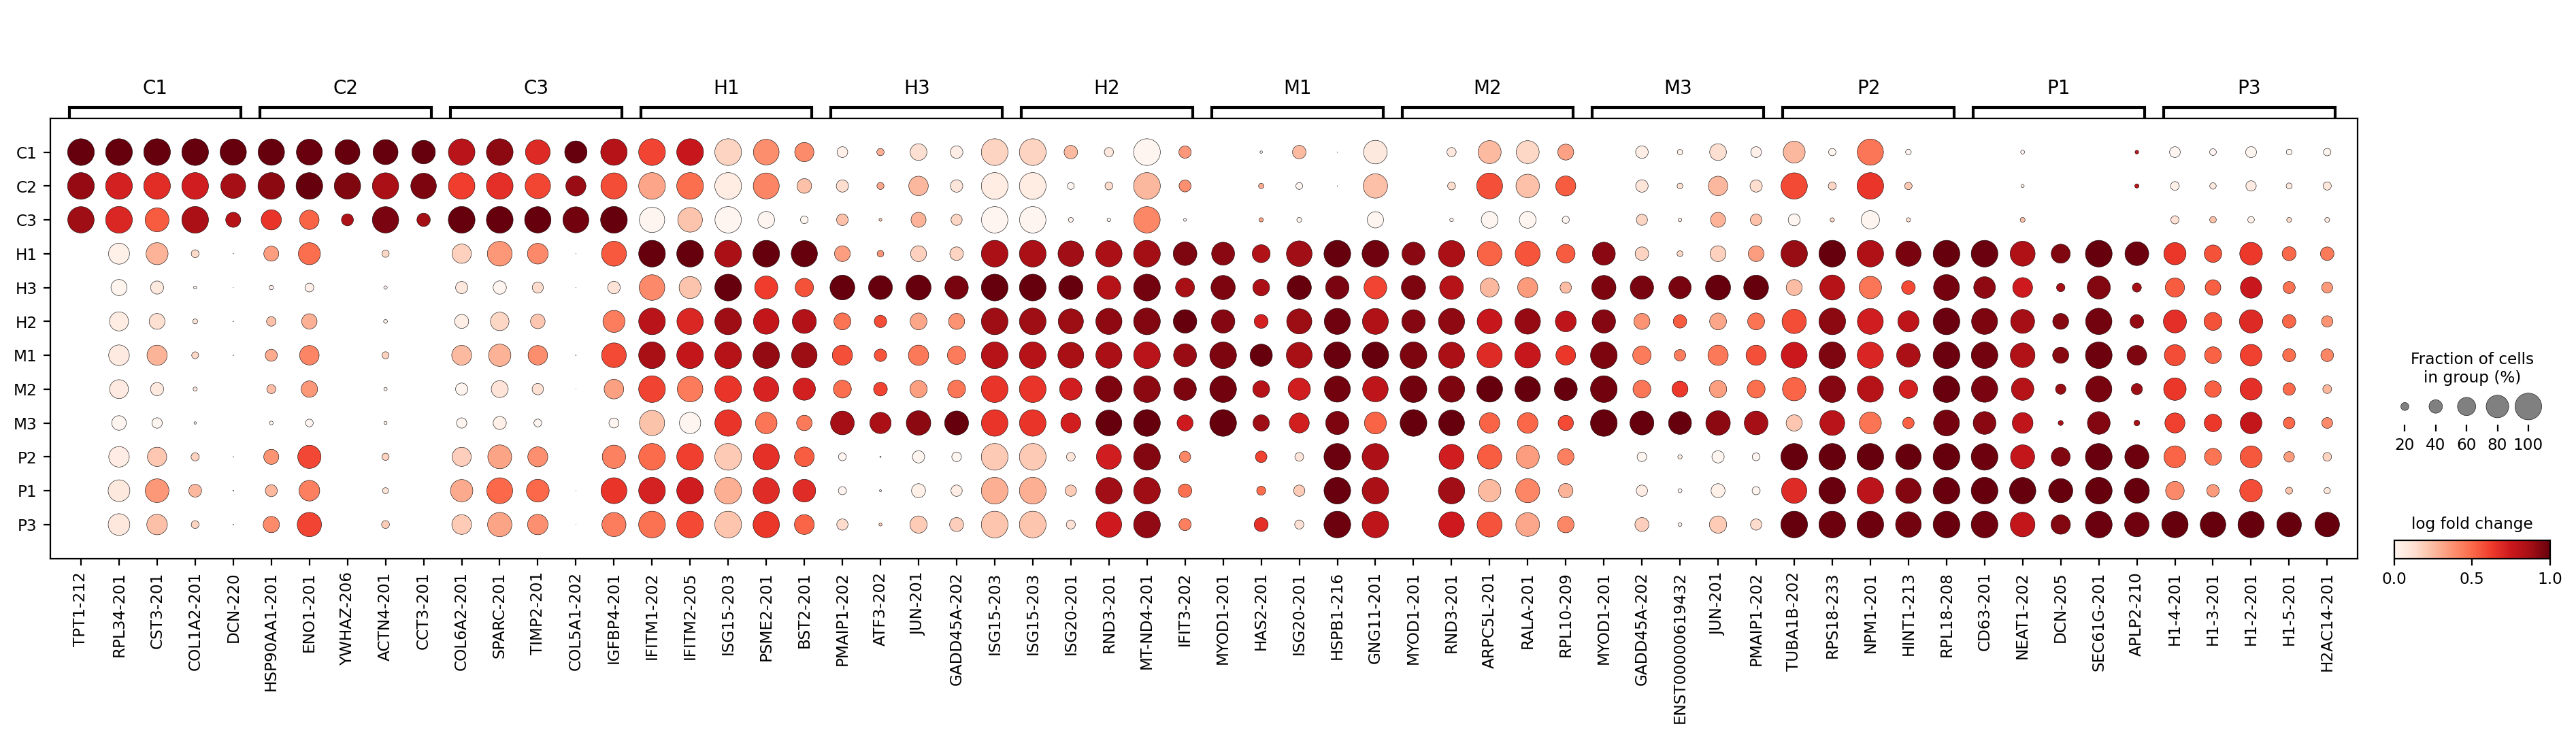

In [39]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    key='cluster_deg',
    n_genes=5,
    values_to_plot='logfoldchanges',
    standard_scale='var',
    min_logfoldchange=1,
    dendrogram=False,
)

In [47]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_deg',
)

sig = get_significant_DEGs(deg, logfc_thresh=0.5)

sig = sig[~sig['names'].str.startswith(('MT', 'RP'))]
sig['gene_name'] = sig['names'].str.split('-', n=1).str[0]

print(f"DE genes: {sig['gene_name'].nunique()}")
print(f"DE isoforms: {sig['names'].nunique()}")

sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 10519

DE genes: 7053
DE isoforms: 10201


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_name
0,mmMYOD1,MYOD1-201,69.678673,33.070446,0.0,0.0,1.000000,33.070446,MYOD1
5,mmMYOD1,RND3-201,66.088799,5.938623,0.0,0.0,0.967757,5.938623,RND3
6,mmMYOD1,HSPB1-216,65.136017,12.094635,0.0,0.0,0.935040,12.094635,HSPB1
7,mmMYOD1,CD63-201,64.788948,33.299835,0.0,0.0,0.929825,33.299835,CD63
8,mmMYOD1,SEC61G-201,64.557671,32.768898,0.0,0.0,0.926505,32.768898,SEC61G


In [51]:
sig = sig.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

sig.groupby('group')[['group', 'names', 'logfoldchanges']].head()

,group,names,logfoldchanges
7,mmMYOD1,CD63-201,33.299835
0,mmMYOD1,MYOD1-201,33.070446
8,mmMYOD1,SEC61G-201,32.768898
11,mmMYOD1,PFDN5-214,32.180340
20,mmMYOD1,CALD1-203,31.177914
57461,siPRRX1,CD63-201,34.414314
57463,siPRRX1,SEC61G-201,33.647278
57466,siPRRX1,PFDN5-214,32.931301
57471,siPRRX1,FXYD5-201,31.789143
57478,siPRRX1,CALD1-203,31.634783


In [174]:
def clean_and_print(header, gene_set):
    genes = sorted(g for g in gene_set if not g.startswith("Z"))
    print(f"\n{header}\n")
    print(", ".join(genes) if genes else "(none)")
    print("\n" + "=" * 50)
    

up = sig[sig['logfoldchanges'] > 10]
up = up[~up['names'].str.startswith('ENST')]

mmMYOD1 = set(up[up['group'] == 'mmMYOD1']['names'])
siPRRX1 = set(up[up['group'] == 'siPRRX1']['names'])
hyb = set(up[up['group'] == 'siPRRX1/mmMYOD1']['names'])

shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

ABCC1-204, ABCE1-202, ACIN1-206, ACSL3-212, ACTN4-208, ADAM12-203, ADAM9-214, ADCY6-202, AKAP10-205, AKAP13-222, AKAP8L-217, AKAP9-201, AKT3-207, ALG13-206, ALG13-211, ALG2-201, ALG8-234, ALPK1-210, AMZ1-203, ANAPC11-204, ANKFY1-208, ANKHD1-202, ANKRD10-206, ANKRD26-202, ANPEP-204, ANTXR1-205, AOPEP-219, AP1AR-206, APBB2-221, APBB2-224, APPL2-203, ARFGEF2-207, ARHGAP21-202, ARHGAP21-207, ARHGAP21-219, ARHGEF2-220, ARPC2-210, ARPP19-201, ASAP1-201, ASAP2-205, ASCC1-207, ASH1L-203, ASH1L-208, ASH1L-AS1-202, ASNSD1-203, ATG12-201, ATP2B4-204, ATP2B4-205, ATP2C1-218, ATP5MG-206, ATXN1-211, ATXN1-212, ATXN2-224, AUP1-201, B3GALNT2-203, BACH1-205, BCLAF1-214, BIRC5-201, BNIP3-204, BPTF-203, BTF3-211, BTG2-202, C11orf65-203, C12orf43-209, C15orf48-203, C1S-221, C1orf146-201, C20orf96-203, CALD1-203, CAMK2D-234, CASP4-207, CAVIN3-204, CBLB-210, CCDC122-205, CCDC25-204, CCDC90B-215, CCNY-208, CCT2-212, CCT3-203, CCT3-211, CD63-201, CDC42BPA-205, CDK1-203, CDK12-207

# Plot isoform UMAPs

In [7]:
def get_transcripts(query, adata=adata, require_uniprot=False):

    df = adata.var[adata.var['gene_name'] == query].copy()
    df['transcript_name'] = df.index

    if require_uniprot:
        df = df[df['UniProtKB'].notna()]
    
    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'UniProtKB',
    ]

    df = df[columns]

    return df

gene_name      gene_type transcript_name                transcript_type UniProtKB
    PRRX1 protein_coding       PRRX1-201                 protein_coding    P54821
    PRRX1 protein_coding       PRRX1-202                 protein_coding       NaN
    PRRX1 protein_coding       PRRX1-204 protein_coding_CDS_not_defined       NaN
    PRRX1 protein_coding       PRRX1-207                 protein_coding    G3V2N3
    PRRX1 protein_coding       PRRX1-208 protein_coding_CDS_not_defined       NaN


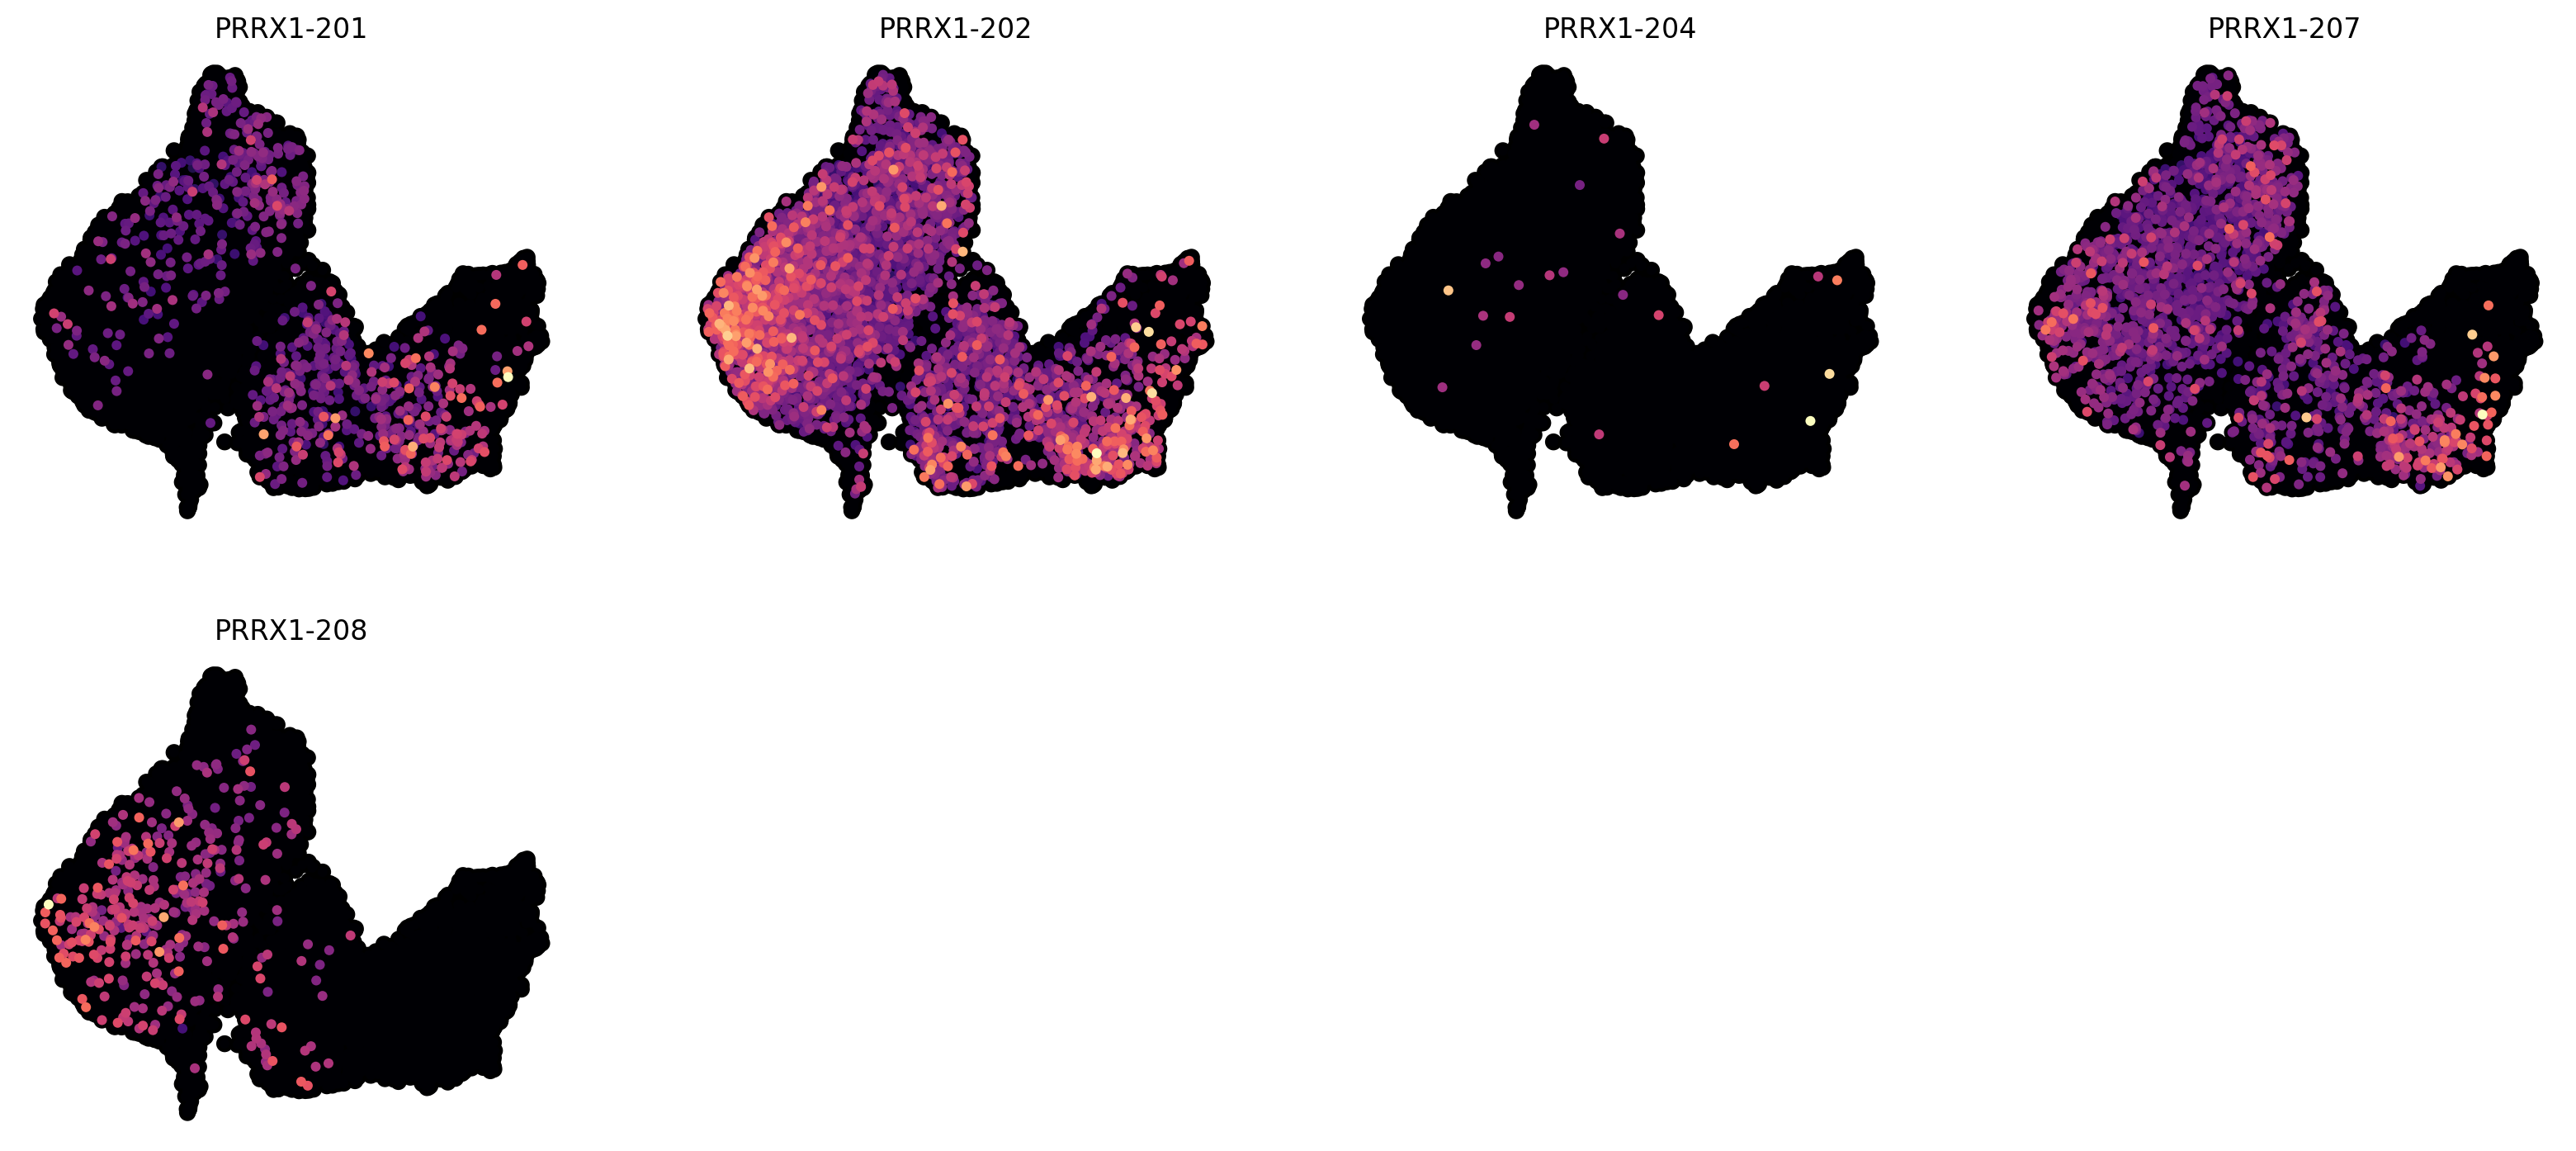

In [9]:
### Good ones
# DYRK1A, RUNX1, STAT6, EID1

query = 'PRRX1'
label_df = get_transcripts(query, require_uniprot=False)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
    layer='log_norm',
)

In [11]:
def calc_pct_expressing(adata, gene, grouping_col='atlas_grouping', threshold=0):
    """
    Calculate percentage of cells expressing a gene per group.
    
    Parameters:
    - adata: AnnData object
    - gene: gene name
    - grouping_col: column in adata.obs with cell groups
    - threshold: expression threshold (default 0, meaning any expression > 0)
    """
    # Get expression values for the gene
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in dataset")
        return None
    
    gene_idx = adata.var_names.get_loc(gene)
    expr = adata.X[:, gene_idx]
    
    # Convert to dense array if sparse
    if hasattr(expr, 'toarray'):
        expr = expr.toarray().flatten()
    else:
        expr = np.asarray(expr).flatten()
    
    # Create dataframe with expression and groups
    df = pd.DataFrame({
        'expression': expr,
        'group': adata.obs[grouping_col].values
    })
    
    # Calculate percentage expressing per group
    pct_expr = df.groupby('group').apply(
        lambda x: 100 * (x['expression'] > threshold).sum() / len(x),
        include_groups=False,
    )
    
    return pct_expr.reset_index().rename(columns={0: 'pct_expressing'})

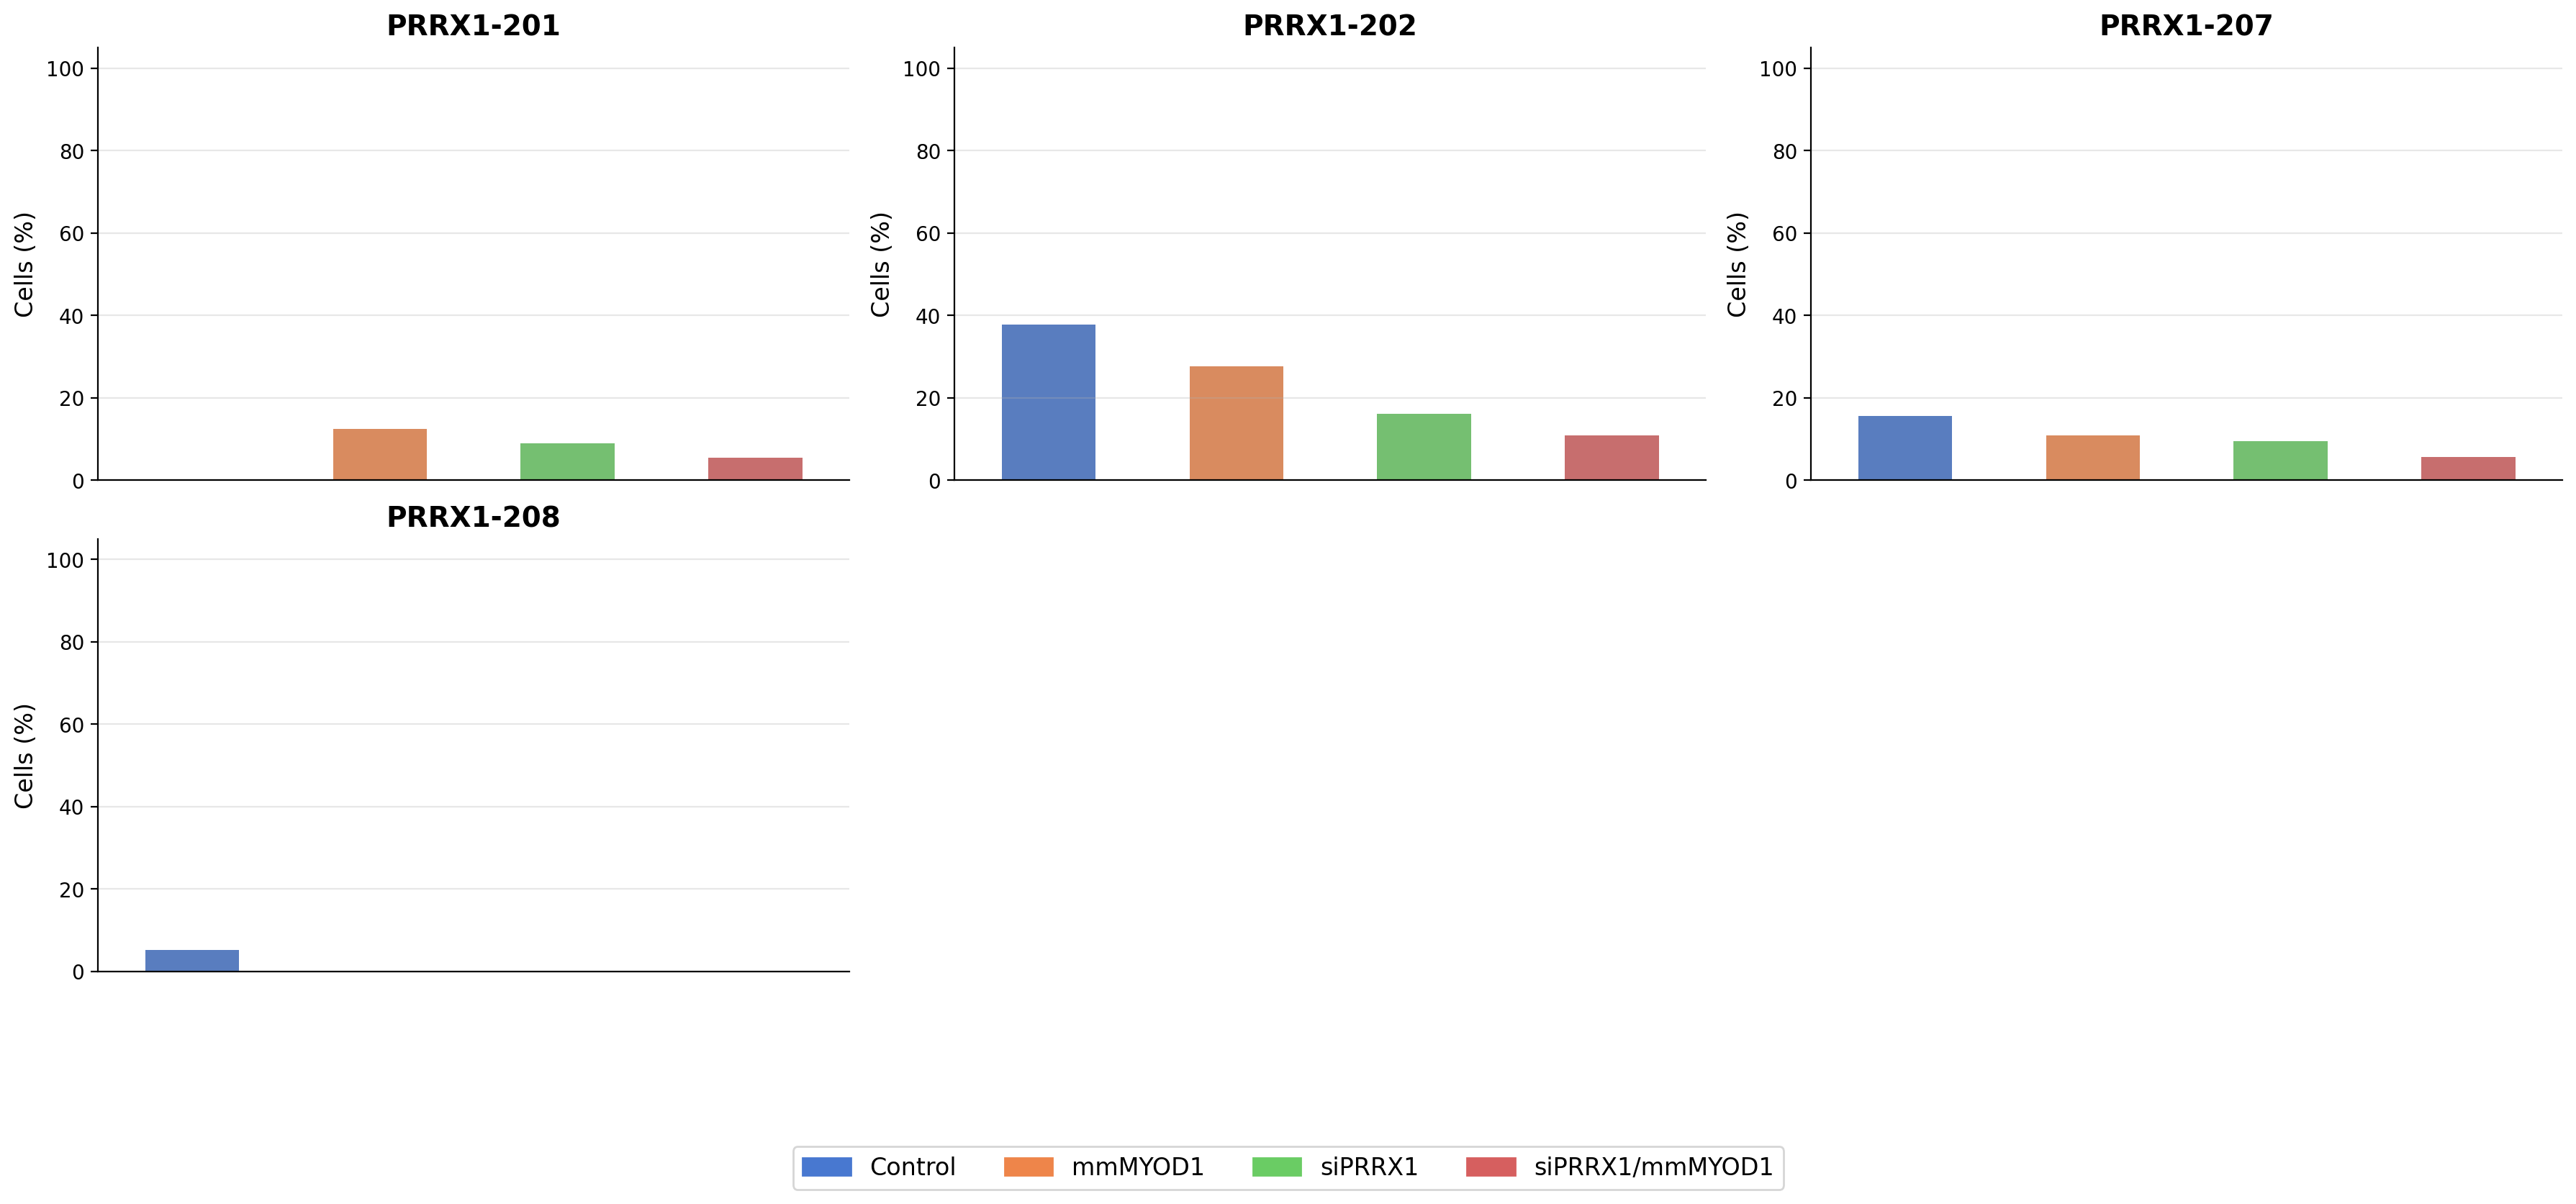

In [18]:
adata.X = adata.layers['log_norm'].copy()

genes = ['PRRX1-201', 'PRRX1-202', 'PRRX1-207', 'PRRX1-208']

count_thresh = 0

n_genes = len(genes)
n_cols = min(3, n_genes)
n_rows = int(np.ceil(n_genes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
if n_genes == 1:
    axes = np.array([axes])
axes = axes.flatten()

grouping = 'pooled_condition'


# Get all unique groups for consistent colors across plots
all_groups = sorted(adata.obs[grouping].unique())

# group_order = [
#     'mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control',
#     'fibroblast', 'fibroblast of dermis', 'muscle fibroblast',
#     'myoblast', 'skeletal muscle myoblast', 'muscle cell',
# ]
    
palette = sns.color_palette('muted', n_colors=len(all_groups))


for i, gene in enumerate(genes):
    ax = axes[i]
    pct_data = calc_pct_expressing(adata, gene, grouping_col=grouping, threshold=count_thresh)
    
    if pct_data is not None:
        
        sns.barplot(
            data=pct_data,
            x='group',
            y='pct_expressing',
            hue='group',
            # order=group_order,
            palette=palette,
            ax=ax,
            legend=False,
            width=0.5,
        )
        
        ax.set_title(gene, fontsize=14, fontweight='bold')
        ax.set_ylabel('Cells (%)', fontsize=12)
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.tick_params(axis='x', bottom=False)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 105])

# Remove extra subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

    
handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(all_groups))]
fig.legend(
    handles,
    all_groups,
    loc='lower center',
    ncol=min(5, len(all_groups)),
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
    fontsize=12
)

sns.despine()
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()